# Flight Delay Project  
## COMP4381 – Data Science and Analytics  

**Instructor:** Ahmed Sabbah  

**Raheeq Mousa:** 1220515  
**Aya Abdakareem:** 1220020  
**Zaid Mousa:** 1221833  

---

In [1]:
print("Welcome to the Flight Delay Project")

Welcome to the Flight Delay Project


In [2]:
pip install gdown

Note: you may need to restart the kernel to use updated packages.


<p style="font-weight:bold;font-size:18px">RUN THE CELL BELOW ONLY IF YOU HAD NOT DOWNLOADED THE DATASET BEFORE!</p>

In [3]:
#YOU DON'T NEED TO RUN THIS CELL EVERYTIME, ONLY IF YOU HADN'T DOWNLOADED THE DATASET
import gdown

file_id = "1BBnDY8JWrR-0faAEmZmKaDEHIZE6FreQ"
url = f"https://drive.google.com/uc?id={file_id}"
output = "data/raw/flight_data_2024.csv"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1BBnDY8JWrR-0faAEmZmKaDEHIZE6FreQ
From (redirected): https://drive.google.com/uc?id=1BBnDY8JWrR-0faAEmZmKaDEHIZE6FreQ&confirm=t&uuid=088e72a7-c545-4667-b3ae-d9e170fddae2
To: C:\Users\user\Desktop\Flight-Delay-Prediction\data\raw\flight_data_2024.csv
100%|██████████| 1.31G/1.31G [03:20<00:00, 6.52MB/s]


'data/raw/flight_data_2024.csv'

In [4]:
import pandas as pd
import numpy as np
import os

In [5]:
df= pd.read_csv('data/raw/flight_data_2024.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_39392\1977606443.py:1: DtypeWarning: Columns (0: cancellation_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('data/raw/flight_data_2024.csv')


First lets remove the cancelled and diverted flights from the dataframe since they don't have arrival delay<br>
and i can't classifiy them whether they are delayed or not

In [6]:
df = df[df["cancelled"] == 0]
df = df[df["diverted"] == 0]

# Sampling

create a new column weather the flight is delayed or not (0 = not delayed / 1 = delayed)

In [7]:
df['delayed']=(df['arr_delay']>=15).astype(int)

Making Stratified Sampling while keepingg aware of the distribution stay the same

In [8]:
print(f"Before a sampling, ratio of delayed flights {df['delayed'].mean()} and ratio of non delayed {(df['delayed']==0).mean()}")

total=1000000
delayed_ratio= df['delayed'].mean()

number_delayed= int(total*delayed_ratio)
number_non_delayed= total-number_delayed

delayed_flights=df[df['delayed']==1].sample(n=number_delayed,random_state=7)
non_delayed_flights=df[df['delayed']==0].sample(n=number_non_delayed,random_state=7)

sampled_flights=pd.concat([delayed_flights,non_delayed_flights]).sample(frac=1, random_state=4)
print(f"After a stratified sampling, ratio of delayed flights {number_delayed/total} and ratio of non delayed {number_non_delayed/total}")

Before a sampling, ratio of delayed flights 0.20817177575532997 and ratio of non delayed 0.79182822424467
After a stratified sampling, ratio of delayed flights 0.208171 and ratio of non delayed 0.791829


Write the sampled data to a new file

In [9]:
os.makedirs('data/sampled', exist_ok=True)

In [10]:
sampled_flights.to_csv('data/sampled/sampled_flights.csv')

# Data Collection and merging the data

In [11]:
df = pd.read_csv('data/sampled/sampled_flights.csv')

In [12]:
df=df[['year','month','day_of_month','day_of_week',
'fl_date','distance',
'origin','origin_city_name','origin_state_nm','dest', 
'dest_city_name','dest_state_nm','op_unique_carrier','op_carrier_fl_num',
'crs_dep_time','crs_arr_time','delayed']]


I fetched the airport data long and lat inorder to get the latitude and longitudde fro the origin and dest airports.

In [13]:
airports = pd.read_csv("data/raw/airports.csv") 
airport_cord = airports[["iata", "lat", "lon"]]

srop the rows that contains na values

In [14]:
airport_cord = airport_cord.dropna()

check the correctness of the lat and lng

In [15]:
airport_cord[(airport_cord['lat'] < -90) | (airport_cord['lat'] > 90)]

,iata,lat,lon


we renamed the columns name of the airports data (airport -> origin) inorder to match the column name in the dataframe
and made a left join to keep all rows from out dataframe, and only add matching airport info (latitude and longitude) when it exists.

In [16]:
airport_cord.columns = ["origin", "origin_lat", "origin_lng"]
df=pd.merge(df,airport_cord,on='origin', how='left')

we renamed the columns name of the airports data (airport -> dest) inorder to match the column name in the dataframe
and made a left join to keep all rows from out dataframe, and only add matching airport info (latitude and longitude) when it exists.

In [17]:
airport_cord.columns = ["dest", "dest_lat", "dest_lng"]
df=pd.merge(df,airport_cord,on='dest', how='left')

In [18]:
print(df['origin_lat'].isna().any())
print(df['origin_lng'].isna().any())
print(df['dest_lat'].isna().any())
print(df['dest_lng'].isna().any())

False
False
False
False


no missing values in origin_lat<br>
no missing values in origin_lng<br>
no missing values in dest_lat<br>
no missing values in dest_lng<br>
Every origin and dest in our dataframe matched with the airport_cord dataframe

In [19]:
df.head(3)

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng
0,2024,1,6,6,2024-01-06,475.0,BNA,"Nashville, TN",Tennessee,MKE,...,Wisconsin,WN,1404.0,1230,1405,0,36.124475,-86.678181,42.946932,-87.897064
1,2024,8,4,7,2024-08-04,2475.0,LAX,"Los Angeles, CA",California,JFK,...,New York,DL,951.0,1100,1957,0,33.942496,-118.408049,40.639928,-73.778692
2,2024,1,12,5,2024-01-12,296.0,SJC,"San Jose, CA",California,BUR,...,California,WN,2485.0,1035,1145,0,37.362995,-121.928621,34.200694,-118.358667


# Preprocessing and Cleaning the data

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   year               1000000 non-null  int64  
 1   month              1000000 non-null  int64  
 2   day_of_month       1000000 non-null  int64  
 3   day_of_week        1000000 non-null  int64  
 4   fl_date            1000000 non-null  str    
 5   distance           1000000 non-null  float64
 6   origin             1000000 non-null  str    
 7   origin_city_name   1000000 non-null  str    
 8   origin_state_nm    1000000 non-null  str    
 9   dest               1000000 non-null  str    
 10  dest_city_name     1000000 non-null  str    
 11  dest_state_nm      1000000 non-null  str    
 12  op_unique_carrier  1000000 non-null  str    
 13  op_carrier_fl_num  1000000 non-null  float64
 14  crs_dep_time       1000000 non-null  int64  
 15  crs_arr_time       1000000 non-null  int64  

## 1. Validate data types

In [21]:
df['fl_date']

0         2024-01-06
1         2024-08-04
2         2024-01-12
3         2024-04-03
4         2024-11-17
             ...    
999995    2024-11-10
999996    2024-05-27
999997    2024-12-12
999998    2024-05-20
999999    2024-07-24
Name: fl_date, Length: 1000000, dtype: str

We converted the fl_date column to datetime type

In [22]:
df['fl_date'] = pd.to_datetime(df['fl_date'])
df

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng
0,2024,1,6,6,2024-01-06,475.0,BNA,"Nashville, TN",Tennessee,MKE,...,Wisconsin,WN,1404.0,1230,1405,0,36.124475,-86.678181,42.946932,-87.897064
1,2024,8,4,7,2024-08-04,2475.0,LAX,"Los Angeles, CA",California,JFK,...,New York,DL,951.0,1100,1957,0,33.942496,-118.408049,40.639928,-73.778692
2,2024,1,12,5,2024-01-12,296.0,SJC,"San Jose, CA",California,BUR,...,California,WN,2485.0,1035,1145,0,37.362995,-121.928621,34.200694,-118.358667
3,2024,4,3,3,2024-04-03,2248.0,JFK,"New York, NY",New York,LAS,...,Nevada,B6,411.0,605,830,0,40.639928,-73.778692,36.080343,-115.152449
4,2024,11,17,7,2024-11-17,1824.0,CLE,"Cleveland, OH",Ohio,LAS,...,Nevada,WN,3473.0,1245,1420,0,41.409407,-81.854691,36.080343,-115.152449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024,11,10,7,2024-11-10,517.0,DEN,"Denver, CO",Colorado,SGU,...,Utah,OO,5051.0,2050,2245,0,39.861667,-104.673167,37.036378,-113.510303
999996,2024,5,27,1,2024-05-27,610.0,LGA,"New York, NY",New York,GSP,...,South Carolina,9E,5486.0,1820,2037,1,40.777242,-73.872606,34.895671,-82.218859
999997,2024,12,12,4,2024-12-12,386.0,SJC,"San Jose, CA",California,LAS,...,Nevada,NK,436.0,2044,2214,0,37.362995,-121.928621,36.080343,-115.152449
999998,2024,5,20,1,2024-05-20,837.0,MSY,"New Orleans, LA",Louisiana,ORD,...,Illinois,MQ,3888.0,600,833,0,29.993272,-90.259028,41.976940,-87.908150


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   year               1000000 non-null  int64         
 1   month              1000000 non-null  int64         
 2   day_of_month       1000000 non-null  int64         
 3   day_of_week        1000000 non-null  int64         
 4   fl_date            1000000 non-null  datetime64[us]
 5   distance           1000000 non-null  float64       
 6   origin             1000000 non-null  str           
 7   origin_city_name   1000000 non-null  str           
 8   origin_state_nm    1000000 non-null  str           
 9   dest               1000000 non-null  str           
 10  dest_city_name     1000000 non-null  str           
 11  dest_state_nm      1000000 non-null  str           
 12  op_unique_carrier  1000000 non-null  str           
 13  op_carrier_fl_num  1000000 non-null  fl

There is no meaning of the op_carrier_fl_num to be a float data, it is just a string id

In [24]:
df['op_carrier_fl_num']=df['op_carrier_fl_num'].astype(str)
df

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng
0,2024,1,6,6,2024-01-06,475.0,BNA,"Nashville, TN",Tennessee,MKE,...,Wisconsin,WN,1404.0,1230,1405,0,36.124475,-86.678181,42.946932,-87.897064
1,2024,8,4,7,2024-08-04,2475.0,LAX,"Los Angeles, CA",California,JFK,...,New York,DL,951.0,1100,1957,0,33.942496,-118.408049,40.639928,-73.778692
2,2024,1,12,5,2024-01-12,296.0,SJC,"San Jose, CA",California,BUR,...,California,WN,2485.0,1035,1145,0,37.362995,-121.928621,34.200694,-118.358667
3,2024,4,3,3,2024-04-03,2248.0,JFK,"New York, NY",New York,LAS,...,Nevada,B6,411.0,605,830,0,40.639928,-73.778692,36.080343,-115.152449
4,2024,11,17,7,2024-11-17,1824.0,CLE,"Cleveland, OH",Ohio,LAS,...,Nevada,WN,3473.0,1245,1420,0,41.409407,-81.854691,36.080343,-115.152449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024,11,10,7,2024-11-10,517.0,DEN,"Denver, CO",Colorado,SGU,...,Utah,OO,5051.0,2050,2245,0,39.861667,-104.673167,37.036378,-113.510303
999996,2024,5,27,1,2024-05-27,610.0,LGA,"New York, NY",New York,GSP,...,South Carolina,9E,5486.0,1820,2037,1,40.777242,-73.872606,34.895671,-82.218859
999997,2024,12,12,4,2024-12-12,386.0,SJC,"San Jose, CA",California,LAS,...,Nevada,NK,436.0,2044,2214,0,37.362995,-121.928621,36.080343,-115.152449
999998,2024,5,20,1,2024-05-20,837.0,MSY,"New Orleans, LA",Louisiana,ORD,...,Illinois,MQ,3888.0,600,833,0,29.993272,-90.259028,41.976940,-87.908150


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   year               1000000 non-null  int64         
 1   month              1000000 non-null  int64         
 2   day_of_month       1000000 non-null  int64         
 3   day_of_week        1000000 non-null  int64         
 4   fl_date            1000000 non-null  datetime64[us]
 5   distance           1000000 non-null  float64       
 6   origin             1000000 non-null  str           
 7   origin_city_name   1000000 non-null  str           
 8   origin_state_nm    1000000 non-null  str           
 9   dest               1000000 non-null  str           
 10  dest_city_name     1000000 non-null  str           
 11  dest_state_nm      1000000 non-null  str           
 12  op_unique_carrier  1000000 non-null  str           
 13  op_carrier_fl_num  1000000 non-null  st

## 2. Solving Inconsistency

Here we are checking the string columns, if they have an entry containins additional space (not trimmed string)

In [26]:
str_cols = ['origin', 'origin_city_name', 'origin_state_nm',
            'dest', 'dest_city_name', 'dest_state_nm',
            'op_unique_carrier', 'op_carrier_fl_num']

for c in str_cols:
    raw   = df[c].nunique()
    non_trimmed_strings = df[c].str.strip().str.upper().nunique()
    if raw == non_trimmed_strings:
        print(f"no issues at {c} ({raw} unique values)")
    else:
        print(f"{c}: {raw - non_trimmed_strings} values are not trimmed")

no issues at origin (348 unique values)
no issues at origin_city_name (342 unique values)
no issues at origin_state_nm (52 unique values)
no issues at dest (348 unique values)
no issues at dest_city_name (342 unique values)
no issues at dest_state_nm (52 unique values)
no issues at op_unique_carrier (15 unique values)
no issues at op_carrier_fl_num (6725 unique values)


Here we are checking the string columns, if they have an entry is repeated with other cases (such as: BNA -> bna, Bna)

In [27]:
str_cols = ['origin', 'origin_city_name', 'origin_state_nm',
            'dest', 'dest_city_name', 'dest_state_nm',
            'op_unique_carrier', 'op_carrier_fl_num']
for c in str_cols:
    raw   = df[c].nunique()
    capital_strings = df[c].str.upper().nunique() #this convert the string to capital then counts unique values
    if raw == capital_strings:
        print(f"No case problems at {c}, and ({raw} unique values)")
    else:
        print(f"There is a case problem at {c}, and ({raw-capital_strings} have problems)")

No case problems at origin, and (348 unique values)
No case problems at origin_city_name, and (342 unique values)
No case problems at origin_state_nm, and (52 unique values)
No case problems at dest, and (348 unique values)
No case problems at dest_city_name, and (342 unique values)
No case problems at dest_state_nm, and (52 unique values)
No case problems at op_unique_carrier, and (15 unique values)
No case problems at op_carrier_fl_num, and (6725 unique values)


In [28]:
(df["day_of_month"] != df["fl_date"].dt.day).any()

np.False_

In [29]:
df[df["day_of_week"] != df["fl_date"].dt.dayofweek]["day_of_week"].value_counts()

day_of_week
1    150977
5    149603
7    147383
4    147093
2    138160
3    137664
6    129120
Name: count, dtype: int64

In [30]:
(df["day_of_week"]-1 != df["fl_date"].dt.dayofweek).any()

np.False_

i wrote df["day_of_week"]-1 because the day_of_week in this dataset is encoded 1-7 instead of 0-6

In [31]:
(df["month"] != df["fl_date"].dt.month).any()

np.False_

In [32]:
(df["year"] != df["fl_date"].dt.year).any()

np.False_

In [33]:
#check if there is zero ot negative distances
df[df['distance']<=0]

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng


Here we check if there is an unusual arrival and departure time

In [34]:
df[(df['crs_dep_time'] > 2359) | (df['crs_dep_time'] < 0)]
df[(df['crs_arr_time'] > 2359) | (df['crs_arr_time'] < 0)]

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng


There are no unsual scheduled departure and arrival time

## 3. Duplicates

In [35]:
df[df.duplicated()]

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,dest_state_nm,op_unique_carrier,op_carrier_fl_num,crs_dep_time,crs_arr_time,delayed,origin_lat,origin_lng,dest_lat,dest_lng


No duplicates appeared in the dataframe

## 4. Missing data

In [36]:
df.isna().sum()

year                 0
month                0
day_of_month         0
day_of_week          0
fl_date              0
distance             0
origin               0
origin_city_name     0
origin_state_nm      0
dest                 0
dest_city_name       0
dest_state_nm        0
op_unique_carrier    0
op_carrier_fl_num    0
crs_dep_time         0
crs_arr_time         0
delayed              0
origin_lat           0
origin_lng           0
dest_lat             0
dest_lng             0
dtype: int64

As you see there are no Missing data in the dataframe

## 5. Outliers

In [37]:
df['distance_zscore']= (df['distance']-df['distance'].mean())/df['distance'].std()
df['distance_outlier'] = df['distance_zscore'].apply(lambda x: abs(x) >= 3)
df["distance_outlier"].value_counts()

distance_outlier
False    991429
True       8571
Name: count, dtype: int64

In [38]:
(df["distance_outlier"]==True).sum()/len(df["distance_outlier"])

np.float64(0.008571)

Only 0.86% of flights are distance outliers, that means the data is consistent.<br>
there exists some extremly short routes<br>
and exists some extremly long routes<br>

# Add features

Add a season column for the flights

In [39]:
seasons = []

for m in df['month']:
    if m <= 2:
        seasons.append('winter')
    elif m <= 5:
        seasons.append('spring')
    elif m <= 8:
        seasons.append('summer')
    else:
        seasons.append('fall')

df['season'] = seasons

A feature checking wheather the date is a weekend or not

In [40]:
df['is_weekend'] = df['day_of_week'] >= 6

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   year               1000000 non-null  int64         
 1   month              1000000 non-null  int64         
 2   day_of_month       1000000 non-null  int64         
 3   day_of_week        1000000 non-null  int64         
 4   fl_date            1000000 non-null  datetime64[us]
 5   distance           1000000 non-null  float64       
 6   origin             1000000 non-null  str           
 7   origin_city_name   1000000 non-null  str           
 8   origin_state_nm    1000000 non-null  str           
 9   dest               1000000 non-null  str           
 10  dest_city_name     1000000 non-null  str           
 11  dest_state_nm      1000000 non-null  str           
 12  op_unique_carrier  1000000 non-null  str           
 13  op_carrier_fl_num  1000000 non-null  st

We created the time_of_day feature ('afternoon','morning',...) 

In [42]:
df['departure_hour'] = df['crs_dep_time'] // 100

In [43]:
result = []

for h in df['departure_hour']:
    if 5 <= h <= 11:
        result.append('morning')
    elif 12 <= h <= 16:
        result.append('afternoon')
    elif 17 <= h <= 20:
        result.append('evening')
    else:
        result.append('night')

df['period_of_day'] = result

In [44]:
df.head(3)

,year,month,day_of_month,day_of_week,fl_date,distance,origin,origin_city_name,origin_state_nm,dest,...,origin_lat,origin_lng,dest_lat,dest_lng,distance_zscore,distance_outlier,season,is_weekend,departure_hour,period_of_day
0,2024,1,6,6,2024-01-06,475.0,BNA,"Nashville, TN",Tennessee,MKE,...,36.124475,-86.678181,42.946932,-87.897064,-0.601835,False,winter,True,12,afternoon
1,2024,8,4,7,2024-08-04,2475.0,LAX,"Los Angeles, CA",California,JFK,...,33.942496,-118.408049,40.639928,-73.778692,2.746703,False,summer,True,11,morning
2,2024,1,12,5,2024-01-12,296.0,SJC,"San Jose, CA",California,BUR,...,37.362995,-121.928621,34.200694,-118.358667,-0.901530,False,winter,False,10,morning


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 27 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   year               1000000 non-null  int64         
 1   month              1000000 non-null  int64         
 2   day_of_month       1000000 non-null  int64         
 3   day_of_week        1000000 non-null  int64         
 4   fl_date            1000000 non-null  datetime64[us]
 5   distance           1000000 non-null  float64       
 6   origin             1000000 non-null  str           
 7   origin_city_name   1000000 non-null  str           
 8   origin_state_nm    1000000 non-null  str           
 9   dest               1000000 non-null  str           
 10  dest_city_name     1000000 non-null  str           
 11  dest_state_nm      1000000 non-null  str           
 12  op_unique_carrier  1000000 non-null  str           
 13  op_carrier_fl_num  1000000 non-null  st

In [46]:
df.to_csv('data/processed/processed_flights.csv')

# Data visualizations and interpretation

In [48]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv('data/processed/processed_flights.csv')
print(df.shape)

(1000000, 28)


# Data Distribtion

Explore the data and the distribution for them

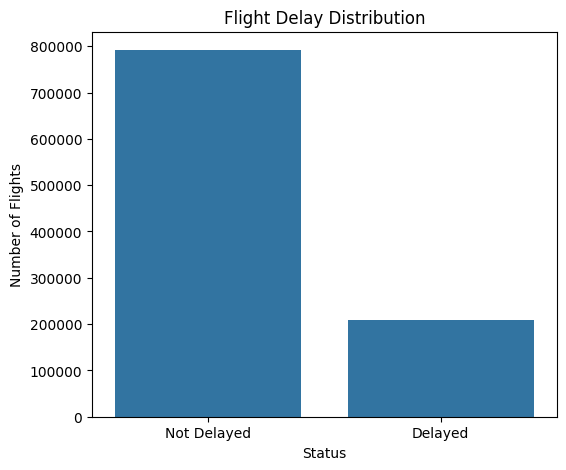

In [52]:
delay_counts = df['delayed'].value_counts()

plt.figure(figsize=(6,5))
sns.barplot(
    x=['Not Delayed', 'Delayed'],
    y=delay_counts.values
)

plt.title('Flight Delay Distribution')
plt.ylabel('Number of Flights')
plt.xlabel('Status')

plt.show()

This figure shows the distribution of data between the delayed and not Delayed fields.<br>
It shows that the not delayed flights around 800K record and the deleayed ones around 200K record.<br>
The dataset is imbalanced but it is also real data because it shows the real flights.

In [53]:
delay_ratio = df['delayed'].mean() * 100

print(f"{delay_ratio:.2f}% of flights are delayed.")

20.82% of flights are delayed.


This shows the ratio of the delayed flights with all data in dataset<br>
It is a normal ratio beacause there is no flight have a 50% to delayed, it is ralated on a multiple factors to be delayed

# Delays by Month

Need to see if there is a relation between the months in the year and the delay flights or not?

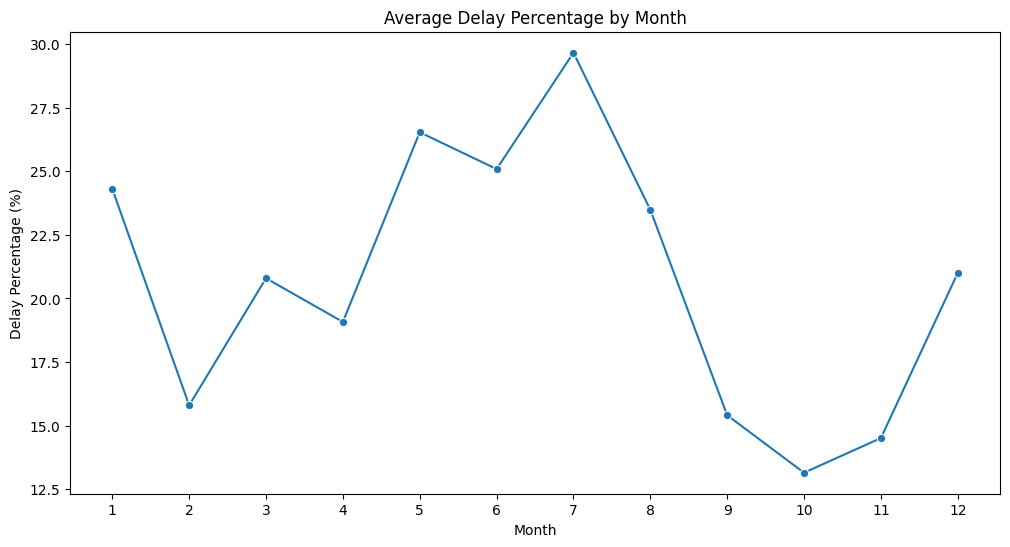

In [55]:
monthly_delay = df.groupby('month')['delayed'].mean() * 100

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_delay.index,
    y=monthly_delay.values,
    marker='o'
)

plt.title('Average Delay Percentage by Month')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')

plt.xticks(range(1,13))

plt.show()

In [57]:
monthly_delay.sort_values(ascending=False)

month
7     29.659562
5     26.533636
6     25.086879
1     24.305657
8     23.487988
12    21.003146
3     20.795063
4     19.078327
2     15.801180
9     15.411445
11    14.514677
10    13.152011
Name: delayed, dtype: float64

<br>
This Shows the average delayed for every month in the year from the figure and ratios <br>
We can see that the summer season has the most delayed because the high congestion in holidays<br>
And the winter months after them because the weather conditions and chrismas holiday


# Delays by Day of week

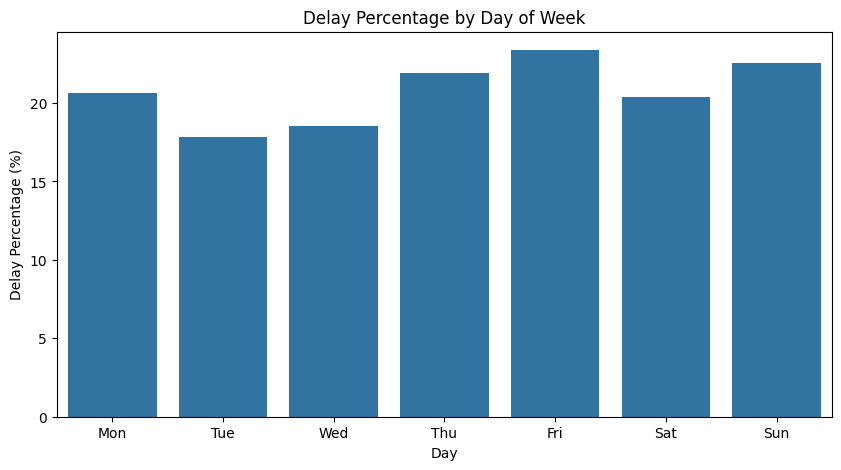

In [58]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

weekly_delay = df.groupby('day_of_week')['delayed'].mean() * 100

plt.figure(figsize=(10,5))

sns.barplot(
    x=days,
    y=weekly_delay.values
)

plt.title('Delay Percentage by Day of Week')
plt.xlabel('Day')
plt.ylabel('Delay Percentage (%)')

plt.show()

Here we can see that the Friday and Sunday have a little more delayed<br>
The reason is because that they are the weekends of the week so it make more traffic in the Airports and flights

# Delays by Period of Day

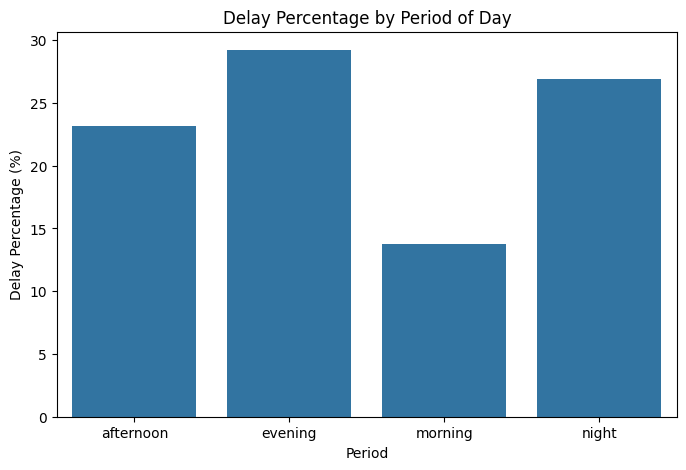

In [61]:
period_delay = df.groupby('period_of_day')['delayed'].mean() * 100

plt.figure(figsize=(8,5))

sns.barplot(
    x=period_delay.index,
    y=period_delay.values
)

plt.title('Delay Percentage by Period of Day')
plt.xlabel('Period')
plt.ylabel('Delay Percentage (%)')

plt.show()

Depends on the figure we can see that the delays usually happend in evening and night <br>
Also means that the flights schedule later in same day are more likely to be delayed comparing it with morning <br>
And in case any one flight delayed in some times it affect many flights after it <br>
And the early time flights if they delayed they affect the flights after that time, for example in case a flight in afternooon is delayed the flights that scheduled in evening and night also delayed

# Distance vs Delay

Need to see if the Distance is a Strong predictor for delays or not?

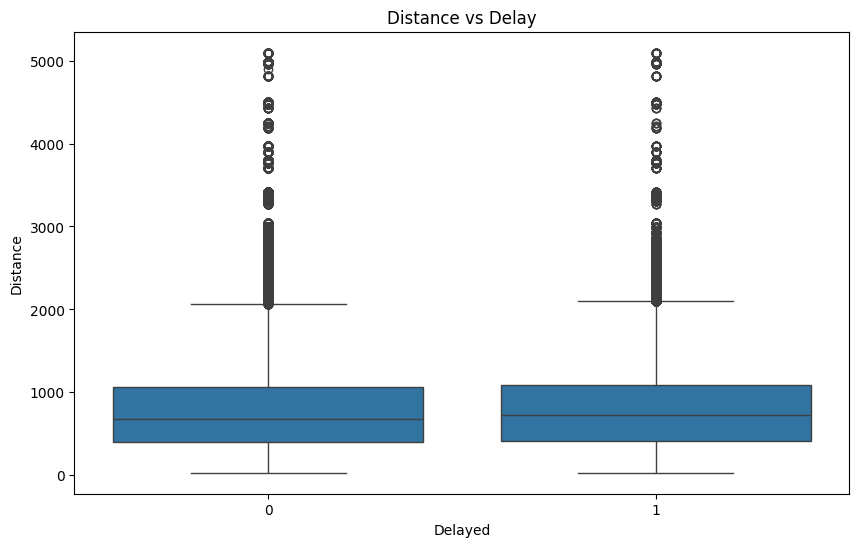

In [69]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='delayed',
    y='distance',
    data=df
)

plt.title('Distance vs Delay')
plt.xlabel('Delayed')
plt.ylabel('Distance')
plt.show()

The Boxplots shows that the distance don't have a big different between the Delayed and not delayed flights. <br>
Both ones have similar median and interquartiles ranges. <br>
The outliers here is the flights that they have a long distnce. <br>
so from what we see the data is similar between the groups that means the distance field is not strong predictor for flight delays.

# Top 10 Airports with highest delay

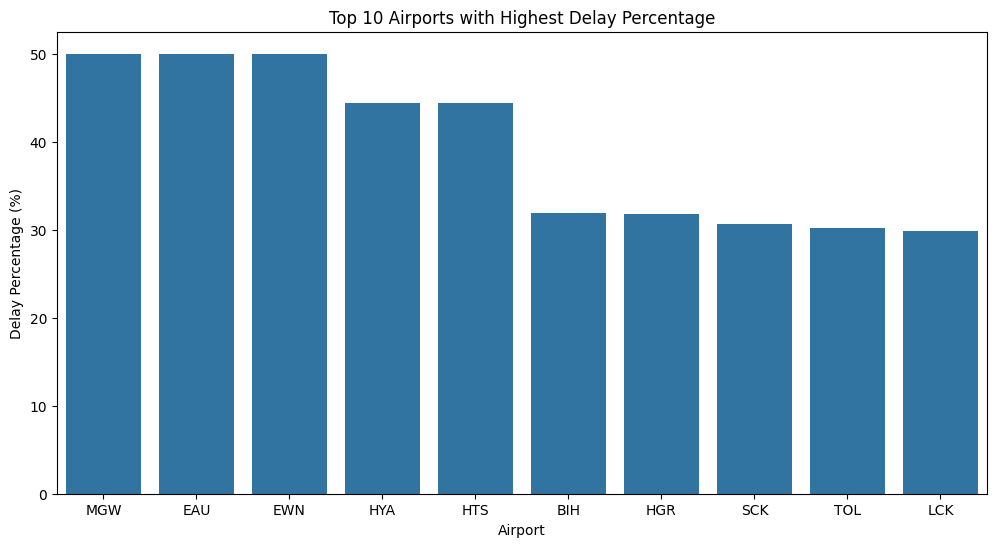

In [70]:
top_airports = (
    df.groupby('origin')['delayed']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    * 100
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_airports.index,
    y=top_airports.values
)

plt.title('Top 10 Airports with Highest Delay Percentage')
plt.xlabel('Airport')
plt.ylabel('Delay Percentage (%)')

plt.show()

As we see some of the Airports have a High ratio in delays, may due to the high traffic volume, weather and place this Airport in and airprt congestion

# Top 10 Airlines with highest delay

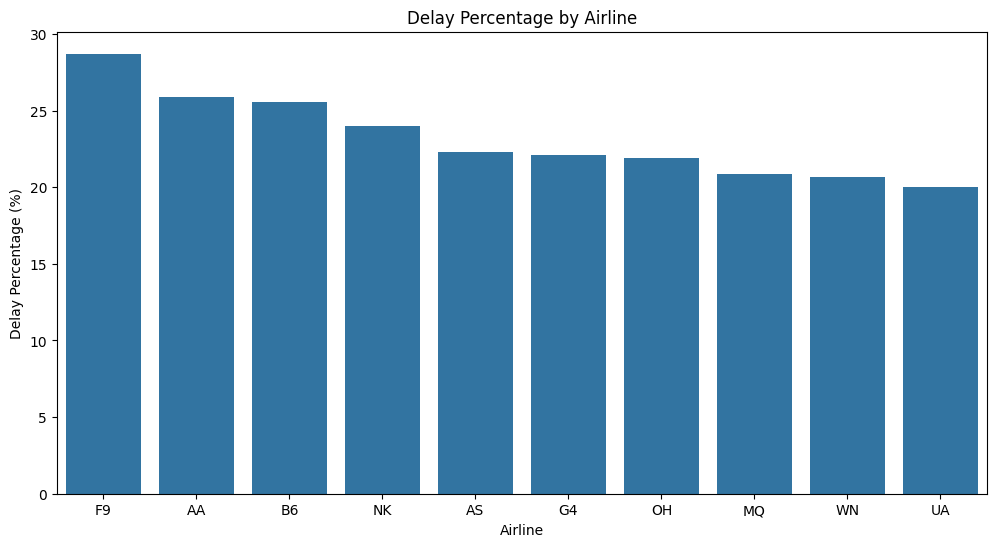

In [72]:
carrier_delay = (
    df.groupby('op_unique_carrier')['delayed']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    * 100
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=carrier_delay.index,
    y=carrier_delay.values
)

plt.title('Delay Percentage by Airline')
plt.xlabel('Airline')
plt.ylabel('Delay Percentage (%)')

plt.show()

Some of the airlines has better schedule than the others thats because the operational efficiency differnt between carriers

# Correlation Heatmap

Need to see the features that can affect the delay column and the features that they don't have a strong effect on it

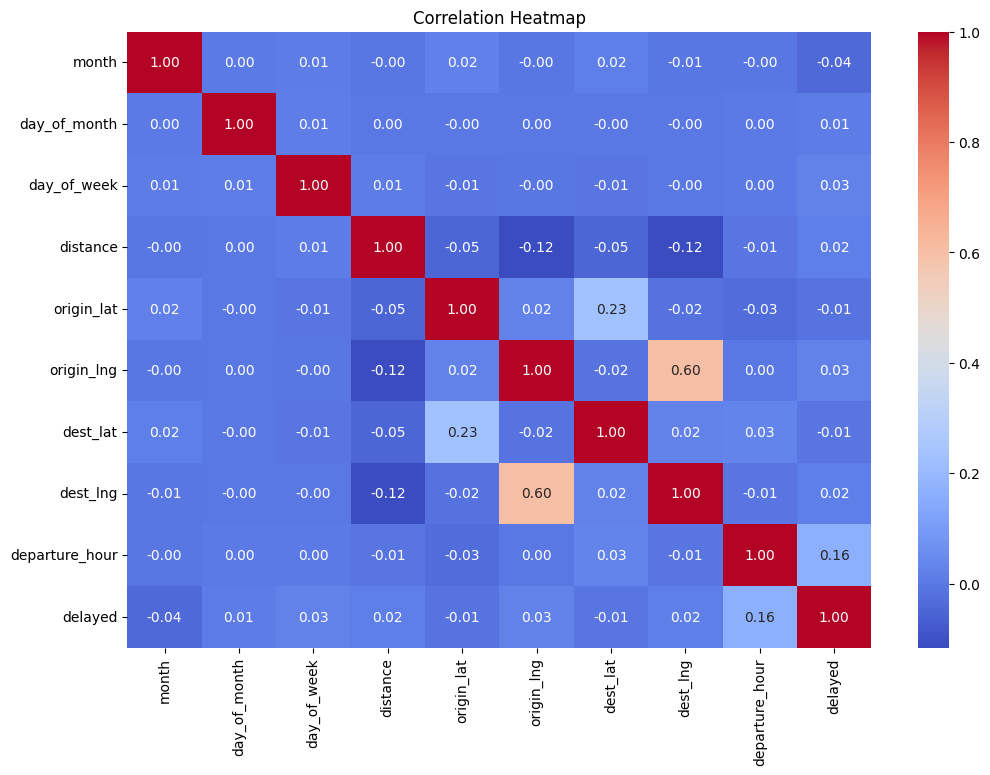

In [73]:
numeric_cols = [
    'month',
    'day_of_month',
    'day_of_week',
    'distance',
    'origin_lat',
    'origin_lng',
    'dest_lat',
    'dest_lng',
    'departure_hour',
    'delayed'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Depends on the heat map most features have a weak linear correlation with delay field, that means the flight delay are influenced by many factors (features) not only one factor.

The strongest relation is the one between departure hour with delay, but is also weak one because the value is 0.16 <br>
But as what i say before that the time of flight delay in day affect the flights after it so thats whay it is stronger a bit than the others

**To prove what i said we will check the delay perventage throw the day**

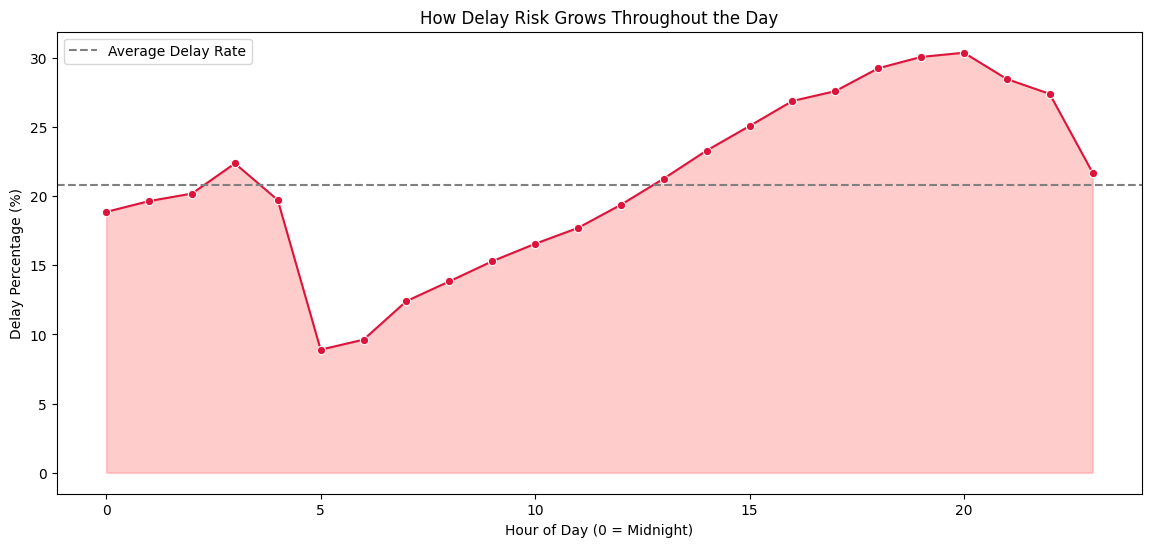

In [80]:
hour_delay = df.groupby('departure_hour')['delayed'].mean() * 100

plt.figure(figsize=(14,6))
sns.lineplot(x=hour_delay.index, y=hour_delay.values, marker='o', color='crimson')
plt.axhline(y=df['delayed'].mean()*100, color='gray', linestyle='--', label='Average Delay Rate')
plt.fill_between(hour_delay.index, hour_delay.values, alpha=0.2, color='red')
plt.title('How Delay Risk Grows Throughout the Day')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Delay Percentage (%)')
plt.legend()
plt.show()

As we see the lowest delay risk is on 5-6 Am and after that the delay risk growth, and when we reach 14 pm the delay exceed the average delay percentage to reach at max the 30% chance to delay

# Delay Heatmap(Month vs Day)

We need to see the if we combine the months with day in the week is they can make a good predictor factor?

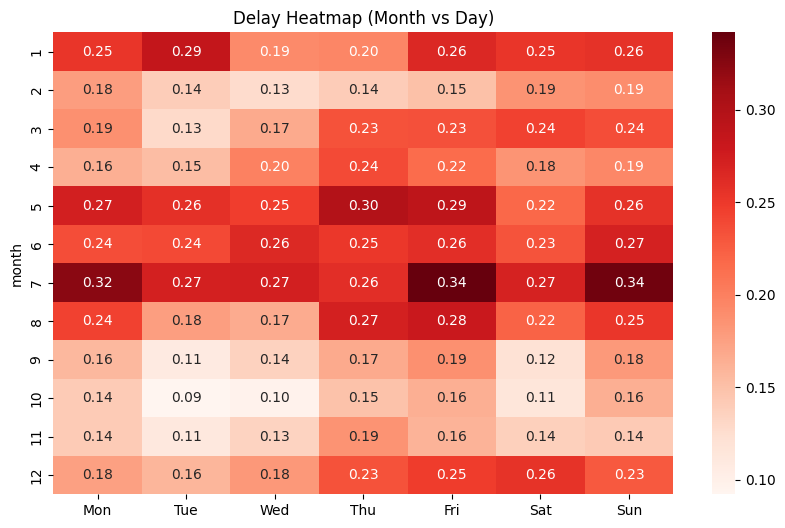

In [86]:
pivot = pd.pivot_table(
    df,
    values='delayed',
    index='month',
    columns='day_of_week',
    aggfunc='mean'
)

# Rename columns from numbers to day names
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    cmap='Reds',
    fmt='.2f'
)
plt.title('Delay Heatmap (Month vs Day)')
plt.show()

Depends on what we see the highest values is for in (Monday, Friday and Sunday) in July <br>
First why the month is July because it is the peak summer travel season in US, because on school summer vaction and some holidays in US in that month like (Independence day). <br>
**Monday** The travelers return from their weekend trips in monday and the bussiness travelers flight out in monday to start their work week also the delayed of sunday flights carry on monday <br>
**Friday** Start of the weekend so people will travel, and the bussiness travelers fly back to home after work days <br>
**Sunday** The end of the weekend so everyone come back home to start their weekend and most of the return flights be afternoon and evening also the delayed of saturday night carry on the sunday morning <br>